In [4]:
import tensorflow as tf
import keras

In [16]:
train_path=r"C:\Users\kumar\Downloads\archive (13)\Cats-and-Dogs-Breed-Dataset-main\TRAIN"
train_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,validation_split=0.2,image_size=(224,224),batch_size=32,shuffle=True,subset='training',seed=42
)

Found 5890 files belonging to 37 classes.
Using 4712 files for training.


In [23]:
print(train_ds.class_names)

['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair', 'chihuahua', 'egyptian_mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'maine_coon', 'miniature_pinscher', 'newfoundland', 'persian', 'pomeranian', 'pug', 'ragdoll', 'russian_blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'siamese', 'sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']


In [24]:
val_ds=tf.keras.utils.image_dataset_from_directory(
    train_path,validation_split=0.2,subset='validation',seed=42,image_size=(224,224),batch_size=32
)

Found 5890 files belonging to 37 classes.
Using 1178 files for validation.


In [26]:
class_name=train_ds.class_names
print(class_name)
print('total class:',len(class_name))

['abyssinian', 'american_bulldog', 'american_pit_bull_terrier', 'basset_hound', 'beagle', 'bengal', 'birman', 'bombay', 'boxer', 'british_shorthair', 'chihuahua', 'egyptian_mau', 'english_cocker_spaniel', 'english_setter', 'german_shorthaired', 'great_pyrenees', 'havanese', 'japanese_chin', 'keeshond', 'leonberger', 'maine_coon', 'miniature_pinscher', 'newfoundland', 'persian', 'pomeranian', 'pug', 'ragdoll', 'russian_blue', 'saint_bernard', 'samoyed', 'scottish_terrier', 'shiba_inu', 'siamese', 'sphynx', 'staffordshire_bull_terrier', 'wheaten_terrier', 'yorkshire_terrier']
total class: 37


In [28]:
import matplotlib.pyplot as plt
import numpy as np

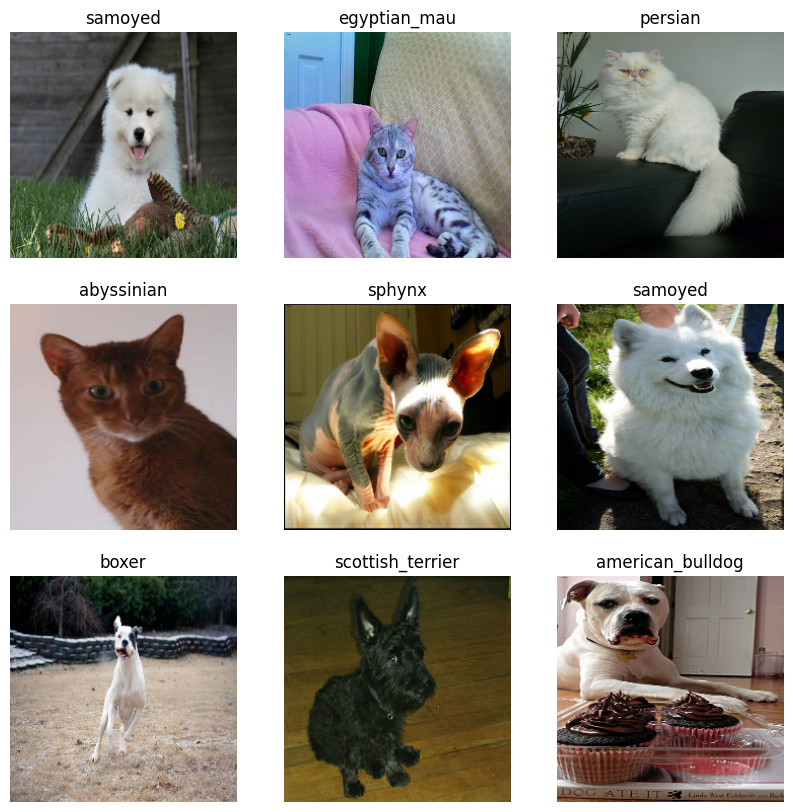

In [32]:
for images,labels in train_ds.take(1):
    plt.figure(figsize=(10,10))
    for i in range(9):
        plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_name[labels[i]])
        plt.axis("off")
plt.show()        

In [34]:
val_ds

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

In [43]:
#train_d=train_ds/255

In [ ]:
model=keras.Sequential([
    keras.layers.Conv2D(filters=20,input_shape=(224,224,3),kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(filters=10,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D(),

    keras.layers.Conv2D(filters=5,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D(),
    keras.layers.Flatten(),
    keras.layers.Dense(1000,activation='relu'), 
    keras.layers.Dropout(0.2),
    keras.layers.Dense(500,activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(100,activation='relu'),
    keras.layers.Dense(len(class_name),activation='sigmoid')
])
model.compile(optimizer='adam',
              metrics=['accuracy'],
              loss='sparse_categorical_crossentropy')

model.fit(train_ds,validation_data=val_ds,epochs=15)

Epoch 1/15


c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\kumar\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


148/148 ━━━━━━━━━━━━━━━━━━━━ 22s 141ms/step - accuracy: 0.0282 - loss: 4.6776 - val_accuracy: 0.0357 - val_loss: 3.6053
Epoch 2/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 21s 141ms/step - accuracy: 0.0454 - loss: 3.5749 - val_accuracy: 0.0323 - val_loss: 3.5942
Epoch 3/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - accuracy: 0.0794 - loss: 3.4475 - val_accuracy: 0.0416 - val_loss: 3.6312
Epoch 4/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.1409 - loss: 3.1633 - val_accuracy: 0.0628 - val_loss: 3.7344
Epoch 5/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 138ms/step - accuracy: 0.2551 - loss: 2.6878 - val_accuracy: 0.0577 - val_loss: 4.0494
Epoch 6/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.4092 - loss: 2.1069 - val_accuracy: 0.0620 - val_loss: 4.8339
Epoch 7/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.5713 - loss: 1.5187 - val_accuracy: 0.0569 - val_loss: 5.4691
Epoch 8/15
148/148 ━━━━━━━━━━━━━━━━━━━━ 20s 135ms/step - accuracy: 0.6700 - loss: 1.0989 - val